In [2]:
import os
import sys
sys.path.append("../")
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

from utils.datasets import GCDataset, Dataset
from agents.gcivl.state.dual import GCIVLDualAgent, get_config
from utils.flax_utils import restore_agent
import ogbench

env_medium, train_dataset_medium, val_dataset_medium = ogbench.make_env_and_datasets(
    dataset_name="antmaze-medium-navigate-v0"
)
env_large, train_dataset_large, val_dataset_large = ogbench.make_env_and_datasets(
    dataset_name="antmaze-large-navigate-v0"
)
agent_config = get_config()

train_dataset_med = GCDataset(Dataset.create(norm=False, **train_dataset_medium), agent_config)
train_dataset_large = GCDataset(Dataset.create(norm=False, **train_dataset_large), agent_config)

example_batch_med = train_dataset_med.sample(1)
example_batch_large = train_dataset_large.sample(1)

agent = GCIVLDualAgent.create(
    0, example_batch_med['observations'], example_batch_med['actions'], agent_config, ex_goals=None
)


In [3]:
agent = restore_agent(
    agent,
    "/home/m_bobrin/dual-goal-representations/weights_antmaze_medium",
    step=3_000_000
)

Restored agent from step 3000000 in /home/m_bobrin/dual-goal-representations/weights_antmaze_medium


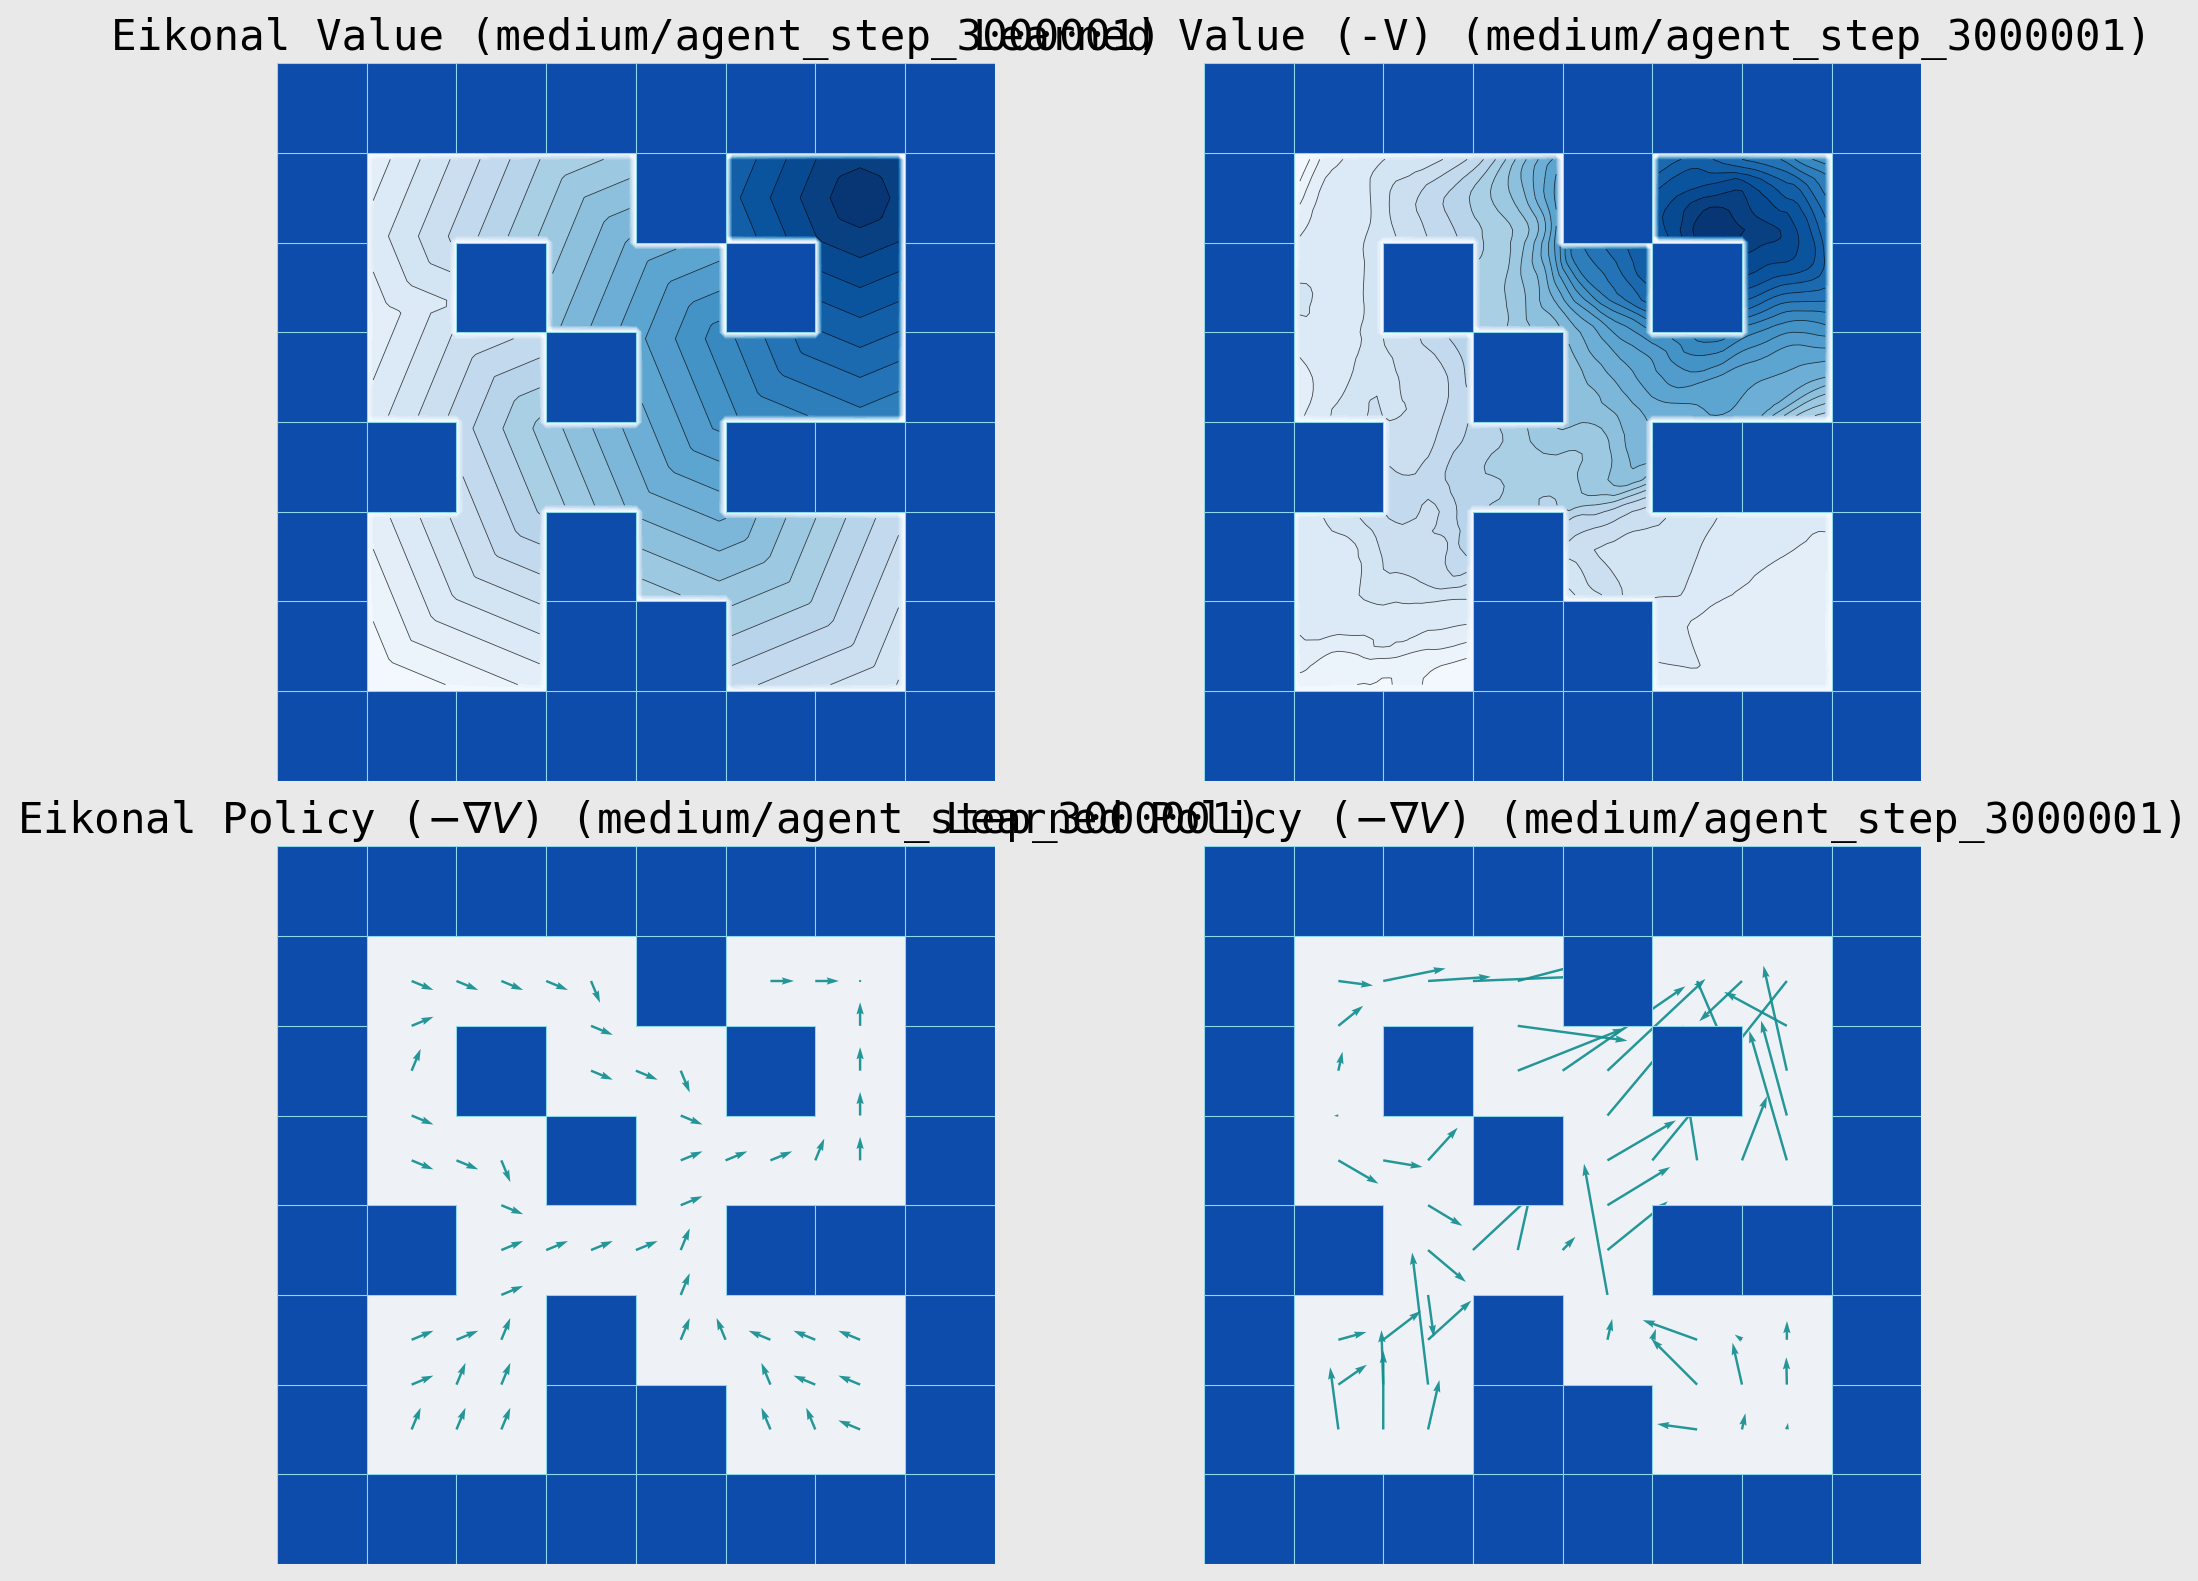

'plots/antmaze_medium_agent_step_3000001_learned_analytic_contours.png'

In [5]:
from utils.antmaze_contours import plot_antmaze_learned_and_analytic
from IPython.display import Image, display
import os

def plot_agent_contours(agent, maze_type='medium', obs_dim=None, env=None, save_dir='plots'):
    """
    Plots and displays learned vs analytic contours for an AntMaze agent.
    
    Args:
        agent: The pretrained agent (e.g., GCIVLDualAgent).
        maze_type: 'medium' or 'large'.
        obs_dim: Total dimension of the observation (e.g., 29). If None, tries to infer from env or agent.
        env: Optional environment to infer obs_dim from.
        save_dir: Directory to save the resulting plot.
    """
    # 1. Infer obs_dim if not provided
    if obs_dim is None:
        if env is not None:
            obs_dim = env.observation_space.shape[0]
    # 2. Ensure save directory exists
    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    # 3. Call the plotting utility
    save_path = plot_antmaze_learned_and_analytic(
        agent=agent,
        maze_type=maze_type,
        save_dir=save_dir,
        obs_dim=obs_dim,
        task_name=f"agent_step_{agent.network.step}"
    )

    # 4. Display in notebook
    display(Image(save_path))
    return save_path

plot_agent_contours(agent, maze_type='medium', env=env_medium)
